In [1]:
import pandas as pd
import glob
import os
import warnings

warnings.filterwarnings("ignore")

In [2]:


# Define folder path
folder_path = "units/cume_units.xlsx"


# Read all files into DataFrames and add filename column
df = pd.read_excel(folder_path, skiprows=2)



In [3]:
folder_path = "units/cume_revenues.xlsx"


revs  = pd.read_excel(folder_path, skiprows=2)


In [4]:
df['product'].unique()

array(['What Remains of Edith Finch',
       'What Remains of Edith Finch - Original Soundtrack', 'Gorogoa',
       'Gorogoa - Original Soundtrack', 'Donut County',
       'Donut County - Original Soundtrack', 'Gone Home', 'Ashen',
       'Flower', 'Outer Wilds', 'Journey', 'Telling Lies',
       'Telling Lies - Original Soundtrack',
       'Ashen - Nightstorm Isle DLC', 'Sayonara Wild Hearts', 'Wattam',
       'Ashen - Original Soundtrack',
       'Sayonara Wild Hearts - Original Soundtrack',
       'Kentucky Route Zero: TV Edition', 'Florence',
       'Florence - Original Soundtrack', 'If Found...',
       'If Found... - Original Soundtrack',
       'Outer Wilds - Original Soundtrack', 'Due Process',
       'The Unfinished Swan', 'I Am Dead',
       'I Am Dead - Original Soundtrack', 'The Pathless',
       'Due Process - Original Soundtrack',
       'Wattam - Original Soundtrack', 'Maquette', 'Mundaun', 'Last Stop',
       'Last Stop - Original Soundtrack', 'Twelve Minutes',
       '

In [5]:
revs

,Date,product,Cumulative Selected Measure
0,2017-03-14,What Remains of Edith Finch,2673.49
1,2017-03-15,What Remains of Edith Finch,7086.67
2,2017-03-16,What Remains of Edith Finch,9976.77
3,2017-03-17,What Remains of Edith Finch,11789.20
4,2017-03-18,What Remains of Edith Finch,14156.59
...,...,...,...
98842,2025-05-14,Wanderstop - Soundtrack,16507.44
98843,2025-05-14,Wattam,1068912.92
98844,2025-05-14,Wattam - Original Soundtrack,4861.78
98845,2025-05-14,What Remains of Edith Finch,19636889.05


In [6]:
df = df.rename({"Cumulative Selected Measure":"units"}, axis=1)

In [7]:
df.drop_duplicates(subset='product', keep='last').tail(25)

,Date,product,units
98822,2025-05-14,Skin Deep - Soundtrack Edition,2
98823,2025-05-14,Skin Deep Soundtrack,476
98824,2025-05-14,Solar Ash,116981
98825,2025-05-14,Solar Ash - Original Soundtrack,1104
98826,2025-05-14,Storyteller,571751
98827,2025-05-14,Storyteller - Original Soundtrack,8815
98828,2025-05-14,Stray,6504177
98829,2025-05-14,Stray - Original Soundtrack,79387
98830,2025-05-14,Telling Lies,177650
98831,2025-05-14,Telling Lies - Original Soundtrack,1301


In [8]:
df['release_date'] = pd.to_datetime(df['Date'])

df['release_date'] = df.groupby('product')['release_date'].transform('min')

df["DAR"] = (df["Date"] - df["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

df["Weeks_from_Release"] = (df["DAR"] // 7) + 1  # Week 1 starts at 0-7 days

#df = df.query("0 <= Weeks_from_Release <=12")

df = df.query("'1/1/2015' <= release_date <='1/1/2026'")

#df = df.groupby(["product",'Date', "Weeks_from_Release"], as_index=False)["units"].max()
df = df.groupby(["product", "Weeks_from_Release"], as_index=False)["units"].max()

In [61]:
title = ['Stray', 'Outer Wilds', "What Remains of Edith Finch"]

In [63]:
current_cume = df.query("product==@title")['units'].values[-1]
current_week = df.query("product==@title")['Weeks_from_Release'].values[-1]

In [65]:
current_week

427

In [67]:
title_df = df.query("product==@title")

In [69]:
title_df

,product,Weeks_from_Release,units
8190,Outer Wilds,1,2411
8191,Outer Wilds,2,15610
8192,Outer Wilds,3,29318
8193,Outer Wilds,4,34116
8194,Outer Wilds,5,36083
...,...,...,...
13718,What Remains of Edith Finch,423,2502506
13719,What Remains of Edith Finch,424,2512225
13720,What Remains of Edith Finch,425,2514503
13721,What Remains of Edith Finch,426,2516195


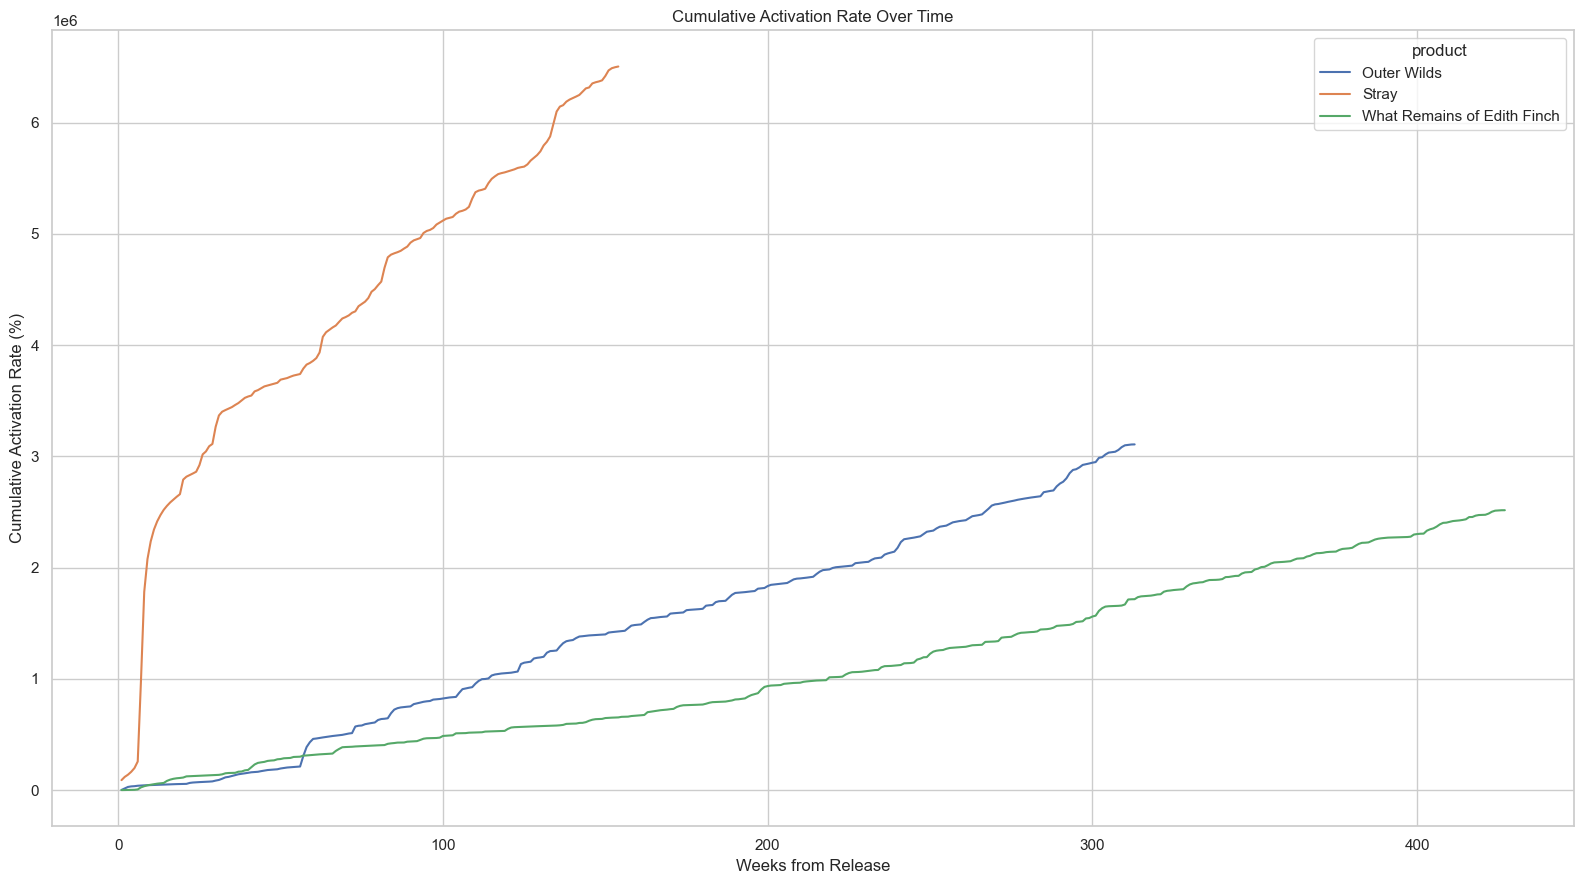

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style for aesthetics
sns.set_theme(style="whitegrid")

# Plot the data
plt.figure(figsize=(16, 9))
sns.lineplot(data=title_df, x="Weeks_from_Release", y="units", hue='product')


# Adding titles and labels
plt.title("Cumulative Activation Rate Over Time")
plt.xlabel("Weeks from Release")
plt.ylabel("Cumulative Activation Rate (%)")

# Show the plot
plt.tight_layout()
plt.show()

In [14]:
title_df['new_units'] = title_df['units'].diff()

In [24]:
ranked_df = df.query("Weeks_from_Release ==1").sort_values(by='units', ascending=False)

In [26]:
range = 0.50

high_end = current_cume * (1 + range)
low_end = current_cume * (1 - range)

In [28]:
low_end

9160.0

In [30]:
df_filtered = ranked_df[~ranked_df['product'].str.contains('Soundtrack', case=False, na=False)]


In [32]:
df_filtered.query("@low_end < units <@high_end")

,product,Weeks_from_Release,units
12367,Twelve Minutes,1,26918
7381,Lushfoil Photography Sim,1,25248
6288,Journey,1,20581
2850,Florence,1,16128
10560,Telling Lies,1,14636
9717,Skin Deep,1,14424
328,Ashen,1,12463
3398,Flower,1,11763
9139,Sayonara Wild Hearts,1,11009
11963,The Unfinished Swan,1,10952


In [20]:
df_filtered['pct_rank'] = df_filtered['units'].rank(pct=True)

In [21]:
df_filtered

,product,Weeks_from_Release,units,pct_rank
8694,Outer Wilds - Echoes of the Eye DLC,2,127666,1.000000
10259,Stray,2,119583,0.976190
12368,Twelve Minutes,2,100322,0.952381
10035,Storyteller,2,50893,0.928571
4075,Gorogoa,2,49011,0.904762
12759,Wanderstop,2,48550,0.880952
6289,Journey,2,40540,0.857143
7382,Lushfoil Photography Sim,2,32478,0.833333
329,Ashen,2,19942,0.809524
2851,Florence,2,19464,0.785714


In [22]:
df_filtered.query("product==@title")

,product,Weeks_from_Release,units,pct_rank
9718,Skin Deep,2,18173,0.761905


In [23]:
stop

NameError: name 'stop' is not defined

# Average Sales Price

In [34]:


# Define folder path
folder_path = "units/cume_units.xlsx"


# Read all files into DataFrames and add filename column
units = pd.read_excel(folder_path, skiprows=2)

units = units.rename({"Cumulative Selected Measure":"units"}, axis=1)

In [35]:
units

,Date,product,units
0,2017-03-14,What Remains of Edith Finch,165
1,2017-03-15,What Remains of Edith Finch,438
2,2017-03-16,What Remains of Edith Finch,614
3,2017-03-17,What Remains of Edith Finch,726
4,2017-03-18,What Remains of Edith Finch,871
...,...,...,...
98842,2025-05-14,Wanderstop - Soundtrack,2233
98843,2025-05-14,Wattam,92803
98844,2025-05-14,Wattam - Original Soundtrack,1031
98845,2025-05-14,What Remains of Edith Finch,2516362


In [36]:

revs = revs.rename({"Cumulative Selected Measure":"revenue"}, axis=1)

revs

,Date,product,revenue
0,2017-03-14,What Remains of Edith Finch,2673.49
1,2017-03-15,What Remains of Edith Finch,7086.67
2,2017-03-16,What Remains of Edith Finch,9976.77
3,2017-03-17,What Remains of Edith Finch,11789.20
4,2017-03-18,What Remains of Edith Finch,14156.59
...,...,...,...
98842,2025-05-14,Wanderstop - Soundtrack,16507.44
98843,2025-05-14,Wattam,1068912.92
98844,2025-05-14,Wattam - Original Soundtrack,4861.78
98845,2025-05-14,What Remains of Edith Finch,19636889.05


In [37]:
combined = pd.merge(units, revs, on=["product", 'Date'])

In [38]:
combined['avg_price'] = combined['revenue'] / combined['units']

In [39]:
combined.query("product=='Stray'")

,Date,product,units,revenue,avg_price
35305,2022-06-02,Stray,13946,3.063829e+05,21.969233
35353,2022-06-03,Stray,36669,7.776848e+05,21.208236
35401,2022-06-04,Stray,51053,1.068529e+06,20.929790
35449,2022-06-05,Stray,63298,1.319098e+06,20.839489
35497,2022-06-06,Stray,73428,1.518895e+06,20.685503
...,...,...,...,...,...
98544,2025-05-10,Stray,6501466,1.487392e+08,22.877798
98615,2025-05-11,Stray,6502749,1.487762e+08,22.878974
98686,2025-05-12,Stray,6503492,1.487975e+08,22.879625
98757,2025-05-13,Stray,6504041,1.488130e+08,22.880091


In [40]:
combined.groupby(by='product')[['units', 'revenue', 'avg_price']].max().to_csv("lifetime_units_and_rev.csv")

In [41]:
combined['release_date'] = pd.to_datetime(combined['Date'])

combined['release_date'] = combined.groupby('product')['release_date'].transform('min')

combined["DAR"] = (combined["Date"] - combined["release_date"]).dt.days
#df_combined["DAR"] = df_combined["DAR"].clip(lower=0)

combined["Weeks_from_Release"] = (combined["DAR"] // 30) + 1  # Week 1 starts at 0-7 days

#df = df.query("0 <= Weeks_from_Release <=12")

combined = combined.query("'1/1/2015' <= release_date <='1/1/2025'")

combined = combined.groupby(["product", "Weeks_from_Release"], as_index=False)["avg_price"].max()

In [42]:
combined['price_delta'] = combined.groupby('product')['avg_price'].diff()

In [43]:
import numpy as np

conditions = [
    (combined['Weeks_from_Release'] > 0) & (combined['Weeks_from_Release'] <= 12),   # 1-12 months (first year)
    (combined['Weeks_from_Release'] > 12) & (combined['Weeks_from_Release'] <= 24), # 13-24 months (second year)
    (combined['Weeks_from_Release'] > 24)  # 24+ months (3+ years)
]

choices = ['First Year', 'Second Year', '3+ Years']

combined['TIER'] = np.select(conditions, choices, default='Unknown')  # 'Unknown' if it doesn't fit any condition

In [44]:
combined.groupby('TIER').avg_price.mean().sort_values()

TIER
3+ Years        8.874677
Second Year    11.196715
First Year     12.968385
Name: avg_price, dtype: float64

In [45]:
combined.groupby('TIER').price_delta.mean().sort_values()

TIER
First Year    -0.19612
Second Year   -0.11414
3+ Years      -0.04809
Name: price_delta, dtype: float64